# 决策树

## 信息熵
表示事件发生的不确定性

公式：
$$
H[x] = - \sum_x p(x) \log_2p(x)
$$

## ID3算法
决策树会选择最大化信息增益来对结点进行划分

信息增益计算：
$$
Info(D) = - \sum_{i=1}^m p_i\log_2(p_i) \\
Info_A(D) = \sum_{j=1}^v \frac{|D_j|}{|D|} * Info(D_j) \\
Gain(A) = Info(D) - Info_A(D)
$$

## C4.5算法
信息增益的方法倾向于首先选择因子数较多的变量

信息增益的改进：增益率
$$
SplitInfo_A(D) = - \sum_{i=1}^v \frac{|D_j|}{|D|} * \log_2(\frac{|D_j|}{|D|}) \\
GrianRate(A) = \frac{Grain(A)}{SplitInfo_A(D)}
$$



In [1]:
from sklearn.feature_extraction import DictVectorizer
from sklearn import tree
from sklearn import preprocessing
import csv

In [5]:
# 读入数据
# numpy只能读数字，所以不用numpy
Dtree = open(r'AllElectronics.csv', 'r')
reader = csv.reader(Dtree)

# 获取第一行数据
headers = reader.__next__()

# 定义两个列表
featureList = []
labelList = []

for row in reader:
  labelList.append(row[-1])
  rowDict = {}
  for i in range(1, len(row)-1):
    # 建立数据字典
    rowDict[headers[i]] = row[i]
  # 数据字典存入list
  featureList.append(rowDict)

featureList

[{'age': 'youth', 'credit_rating': 'fair', 'income': 'high', 'student': 'no'},
 {'age': 'youth',
  'credit_rating': 'excellent',
  'income': 'high',
  'student': 'no'},
 {'age': 'middle_aged',
  'credit_rating': 'fair',
  'income': 'high',
  'student': 'no'},
 {'age': 'senior',
  'credit_rating': 'fair',
  'income': 'medium',
  'student': 'no'},
 {'age': 'senior', 'credit_rating': 'fair', 'income': 'low', 'student': 'yes'},
 {'age': 'senior',
  'credit_rating': 'excellent',
  'income': 'low',
  'student': 'yes'},
 {'age': 'middle_aged',
  'credit_rating': 'excellent',
  'income': 'low',
  'student': 'yes'},
 {'age': 'youth',
  'credit_rating': 'fair',
  'income': 'medium',
  'student': 'no'},
 {'age': 'youth', 'credit_rating': 'fair', 'income': 'low', 'student': 'yes'},
 {'age': 'senior',
  'credit_rating': 'fair',
  'income': 'medium',
  'student': 'yes'},
 {'age': 'youth',
  'credit_rating': 'excellent',
  'income': 'medium',
  'student': 'yes'},
 {'age': 'middle_aged',
  'credit_rat

In [8]:
# 数据转换成01表示
vec = DictVectorizer()
x_data = vec.fit_transform(featureList).toarray()
# 标签转换成01表示
lb = preprocessing.LabelBinarizer()
y_data = lb.fit_transform(labelList)

In [9]:
# 创建决策树模型
model = tree.DecisionTreeClassifier(criterion='entropy')
# 输入数据建立模型
model.fit(x_data, y_data)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='entropy',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

In [11]:
# 测试
x_test = x_data[0]
print(str(model.predict(x_test.reshape(1,-1))))

[0]


## 画出决策树

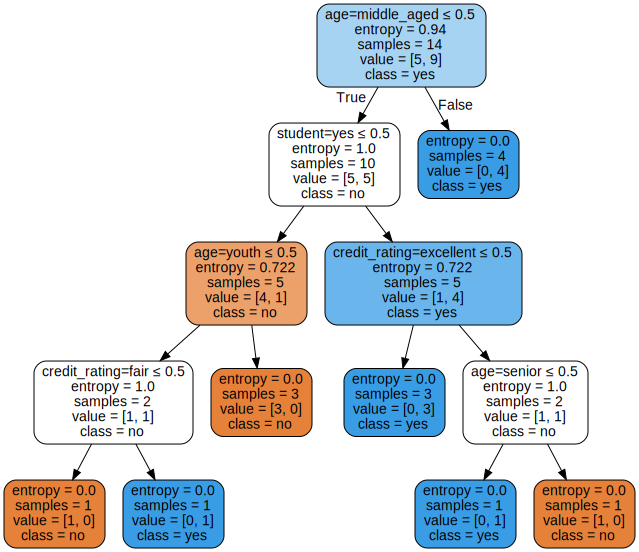

In [14]:
# 导出决策树
import graphviz
dot_data = tree.export_graphviz(model, 
                                out_file=None,
                                feature_names=vec.get_feature_names(),
                                class_names = lb.classes_,
                                filled = True,
                                rounded = True,
                                special_characters = True)
graph = graphviz.Source(dot_data)
# 导出pdf
# graph.render('computer')
graph

## CART算法
CART决策树的生成就是递归地构建二叉决策树的过程。

CART用基尼(Gini)系数最小化准则来进行特征选择，生成二叉树

Gini系数计算：
$$
Gini(D) = 1 - \sum_{i=1}^m p_i^2 \\
Gini_A(D) = \frac{|D_1|}{|D|}Gini(D_1) + \frac{|D_2|}{|D|}Gini(D_2) \\
\Delta Gini(A) = Gini(D) - Gini_A(D)
$$

In [16]:
from sklearn import tree
import numpy as np

In [17]:
# 载入数据
data = np.genfromtxt('cart.csv', delimiter=',')
x_data = data[1:, 1:-1]
y_data = data[1:,-1]

In [21]:
# 创建决策树模型
model = tree.DecisionTreeClassifier()
# 输入数据建立模型
model.fit(x_data, y_data)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

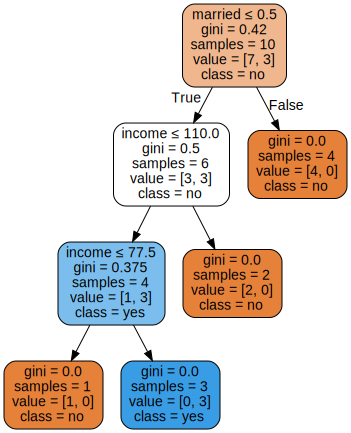

In [22]:
# 导出决策树
import graphviz
dot_data = tree.export_graphviz(model,
                                out_file = None,
                                feature_names = ['house_yes', 'house_no', 'single', 'married', 'divorced', 'income'],
                                class_names = ['no', 'yes'],
                                filled = True,
                                rounded = True,
                                special_characters = True)
graph = graphviz.Source(dot_data)
graph

## 决策树-线性二分类

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from sklearn import tree

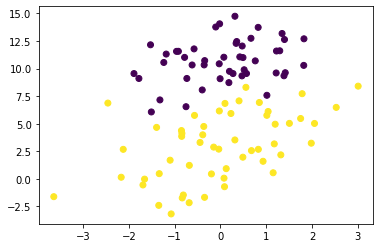

In [24]:
# 载入数据
data = np.genfromtxt('LR-testSet.csv', delimiter=',')
x_data = data[:,:-1]
y_data = data[:,-1]

plt.scatter(x_data[:,0], x_data[:,1], c=y_data)
plt.show()

In [25]:
# 创建决策树模型
model = tree.DecisionTreeClassifier()
# 输入数据建立模型
model.fit(x_data, y_data)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=None, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

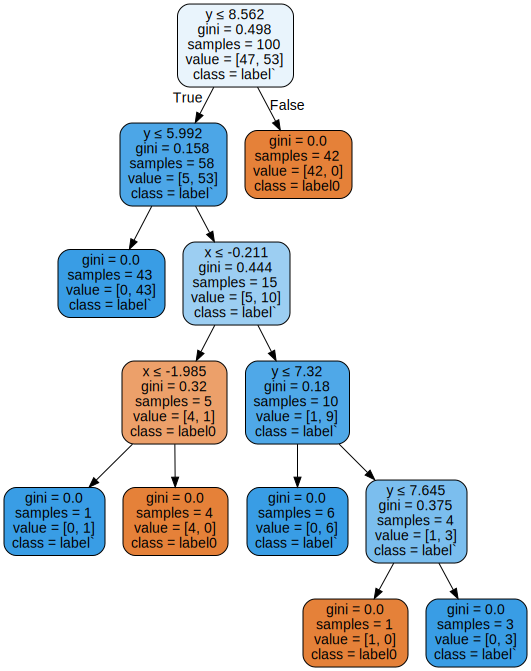

In [26]:
# 导出决策树
import graphviz
dot_data = tree.export_graphviz(model,
                                out_file = None,
                                feature_names = ['x', 'y'],
                                class_names = ['label0', 'label`'],
                                filled = True,
                                rounded = True,
                                special_characters = True)
graph = graphviz.Source(dot_data)
graph

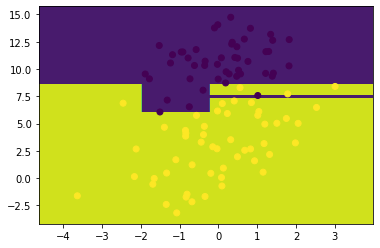

In [29]:
# 输入数据建立模型
model.fit(x_data,y_data)

# 获取数据值所在的范围
x_min, x_max = x_data[:,0].min()-1,x_data[:,0].max()+1
y_min, y_max = x_data[:,1].min()-1,x_data[:,1].max()+1

# 生成网格矩阵
xx, yy = np.meshgrid(np.arange(x_min,x_max,0.02),
                     np.arange(y_min,y_max,0.02))

z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
# 等高线图
cs = plt.contourf(xx, yy, z)
# 样本散点图
plt.scatter(x_data[:, 0], x_data[:,1], c=y_data)
plt.show()

In [33]:
predictions = model.predict(x_data)
print(classification_report(predictions, y_data))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00        47
         1.0       1.00      1.00      1.00        53

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



## 决策树-非线性二分类

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report
from sklearn import tree
from sklearn.model_selection import train_test_split

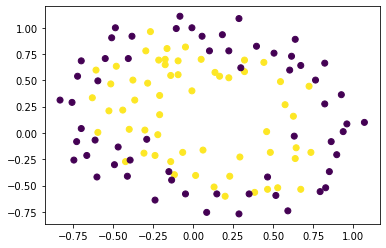

In [35]:
# 载入数据
data = np.genfromtxt('LR-testSet2.txt', delimiter=',')
x_data = data[:, :-1]
y_data = data[:, -1]

plt.scatter(x_data[:,0], x_data[:,1], c=y_data)
plt.show()

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x_data, y_data)
# 设置参数进行剪枝，解决过拟合问题
# max_depth:树的深度
# min_samples_split:内部节点再划分所需最小样本数
model = tree.DecisionTreeClassifier(max_depth=4, min_samples_split=3)
model.fit(x_train, y_train)

DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                       max_depth=4, max_features=None, max_leaf_nodes=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=3,
                       min_weight_fraction_leaf=0.0, presort='deprecated',
                       random_state=None, splitter='best')

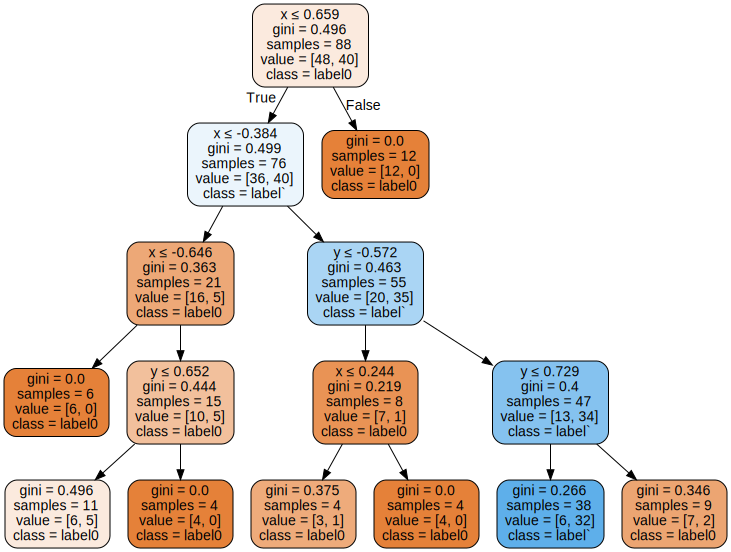

In [60]:
# 导出决策树
import graphviz
dot_data = tree.export_graphviz(model,
                                out_file = None,
                                feature_names = ['x', 'y'],
                                class_names = ['label0', 'label`'],
                                filled = True,
                                rounded = True,
                                special_characters = True)
graph = graphviz.Source(dot_data)
graph

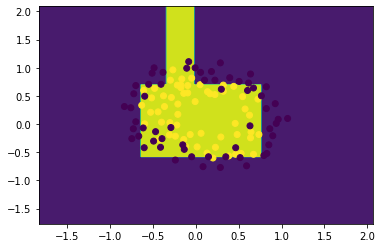

In [61]:
# 输入数据建立模型
model.fit(x_data,y_data)

# 获取数据值所在的范围
x_min, x_max = x_data[:,0].min()-1,x_data[:,0].max()+1
y_min, y_max = x_data[:,1].min()-1,x_data[:,1].max()+1

# 生成网格矩阵
xx, yy = np.meshgrid(np.arange(x_min,x_max,0.02),
                     np.arange(y_min,y_max,0.02))

z = model.predict(np.c_[xx.ravel(), yy.ravel()])
z = z.reshape(xx.shape)
# 等高线图
cs = plt.contourf(xx, yy, z)
# 样本散点图
plt.scatter(x_data[:, 0], x_data[:,1], c=y_data)
plt.show()

In [62]:
predictions = model.predict(x_train)
print(classification_report(predictions, y_train))

              precision    recall  f1-score   support

         0.0       0.69      0.97      0.80        34
         1.0       0.97      0.72      0.83        54

    accuracy                           0.82        88
   macro avg       0.83      0.85      0.82        88
weighted avg       0.86      0.82      0.82        88



In [63]:
predictions = model.predict(x_test)
print(classification_report(predictions, y_test))

              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91        10
         1.0       1.00      0.90      0.95        20

    accuracy                           0.93        30
   macro avg       0.92      0.95      0.93        30
weighted avg       0.94      0.93      0.93        30

